# 08 — LSTM: Red Neuronal Recurrente para Pronóstico de Rentas Cedidas

**Sistema de Análisis y Pronóstico de Rentas Cedidas** | ADRES — Colombia

---

## Arquitectura Analítica

| Fase | Contenido | Método |
|------|-----------|--------|
| **I** | Carga, preprocesamiento y normalización | log1p + MinMaxScaler |
| **II** | Construcción de ventanas temporales | look-back = 12 meses |
| **III** | Arquitectura de la Red LSTM + entrenamiento | Stacked LSTM + Dropout + Early Stopping |
| **IV** | Pronóstico Out-of-Sample | Oct–Dic 2025 vs datos reales |
| **V** | Diagnóstico de residuos y análisis de error | Ljung-Box, Shapiro-Wilk, MAPE por mes |
| **VI** | Comparativa vs modelos lineales y ML | SARIMA, SARIMAX, Prophet, XGBoost |

### Justificación Metodológica

**¿Por qué LSTM?** Las redes Long Short-Term Memory (Hochreiter & Schmidhuber,
1997) poseen mecanismos de compuertas (*forget gate*, *input gate*, *output gate*)
que permiten:

  1. **Memoria selectiva** de patrones estacionales a largo plazo (12 meses).
  2. **Olvido controlado** de ruido y anomalías puntuales.
  3. **Integración de variables exógenas** (IPC, consumo, UPC) en la capa de entrada.

**Limitación explícita:** Con solo 51 meses de serie (Oct 2021 – Dic 2025) y
un look-back de 12 meses, se dispone de 39 muestras efectivas — un reto para
Deep Learning. Se mitiga con:
  - Arquitectura ultraligera (2 capas LSTM, 64 unidades máximo).
  - Regularización agresiva (Dropout 0.2 + Early Stopping).
  - Semilla fija y entrenamiento determinístico para reproducibilidad.

> **Nota para jurados:** Este modelo es un *benchmark* experimental de Deep
> Learning frente a modelos estadísticos clásicos (SARIMA, Prophet) y ML
> (XGBoost). La escasez de datos limita su capacidad de generalización, lo cual
> se documenta exhaustivamente en el reporte de métricas.

---


In [1]:
# ══════════════════════════════════════════════════════════════
# IMPORTACIONES Y CONFIGURACIÓN
# ══════════════════════════════════════════════════════════════
import os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error,
                             mean_absolute_percentage_error,
                             mean_squared_error)

# Semilla global para reproducibilidad completa
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
random.seed(SEED)
np.random.seed(SEED)

# TensorFlow / Keras
import tensorflow as tf
tf.random.set_seed(SEED)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Configuración del proyecto
%run 00_config.py

# Statsmodels para diagnóstico
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

print(f"\n{'='*70}")
print(f"CONFIGURACION LSTM")
print(f"{'='*70}")
print(f"  TensorFlow:        {tf.__version__}")
print(f"  GPU disponible:    {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"  Semilla global:    {SEED}")
print(f"  Periodo:           {FECHA_INICIO} -> {FECHA_FIN}")
print(f"  Entrenamiento:     Oct 2021 -> Sep 2025 (48 meses)")
print(f"  Prueba OOS:        Oct 2025 -> Dic 2025 (3 meses)")


  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
Config cargada -- Datos: BaseRentasVF_limpieza21feb_sin2021_ene_sep.xlsx | Periodo: 2021-10-01 a 2025-12-31
  Tema profesional activo -- DPI 300, tipografia serif, paleta academica

CONFIGURACION LSTM
  TensorFlow:        2.18.0
  GPU disponible:    False
  Semilla global:    42
  Periodo:           2021-10-01 -> 2025-12-31
  Entrenamiento:     Oct 2021 -> Sep 2025 (48 meses)
  Prueba OOS:        Oct 2025 -> Dic 2025 (3 meses)


---

## Fase I — Carga, Preprocesamiento y Normalización

### Protocolo de Curaduría

1. **Filtro de periodo**: Se utiliza la serie completa Oct 2021 – Dic 2025
   (51 meses). El periodo anómalo 2020 – Sep 2021 (pandemia COVID-19) ya fue
   excluido en la etapa de limpieza del AED.

2. **Transformación log1p**: Estabiliza la varianza y mitiga el sesgo de
   transacciones de gran magnitud detectadas en el análisis exploratorio.

$$y_t^* = \log(1 + y_t)$$

3. **Normalización MinMaxScaler**: Escala todas las variables al rango $[0, 1]$
   para que las compuertas de la LSTM operen con gradientes estables en la
   función sigmoide y tangente hiperbólica.

$$\tilde{x}_i = \frac{x_i - \min(x_{train})}{\max(x_{train}) - \min(x_{train})}$$

> **Importante:** El scaler se ajusta **exclusivamente** sobre el conjunto de
> entrenamiento para evitar *data leakage*.


PREPROCESAMIENTO COMPLETADO
  Serie original:     51 meses (2021-10-01 -> 2025-12-01)
  Serie efectiva:     50 meses (tras eliminar NaN de Lag_1)
  Entrenamiento:      47 meses (2021-11-01 -> 2025-09-01)
  Prueba OOS:         3 meses (2025-10-01 -> 2025-12-01)
  Variables entrada:  9
    - y_log
    - Lag_1
    - IPC_Idx
    - Consumo_Hogares
    - UPC
    - SMLV_COP
    - Mes_sin
    - Mes_cos
    - Es_Pico

  MinMaxScaler ajustado exclusivamente sobre entrenamiento
  Rango X train: [0.0000, 1.0000]
  Rango y train: [0.0000, 1.0000]
  📊 Figura guardada: 08_lstm_serie_split.png


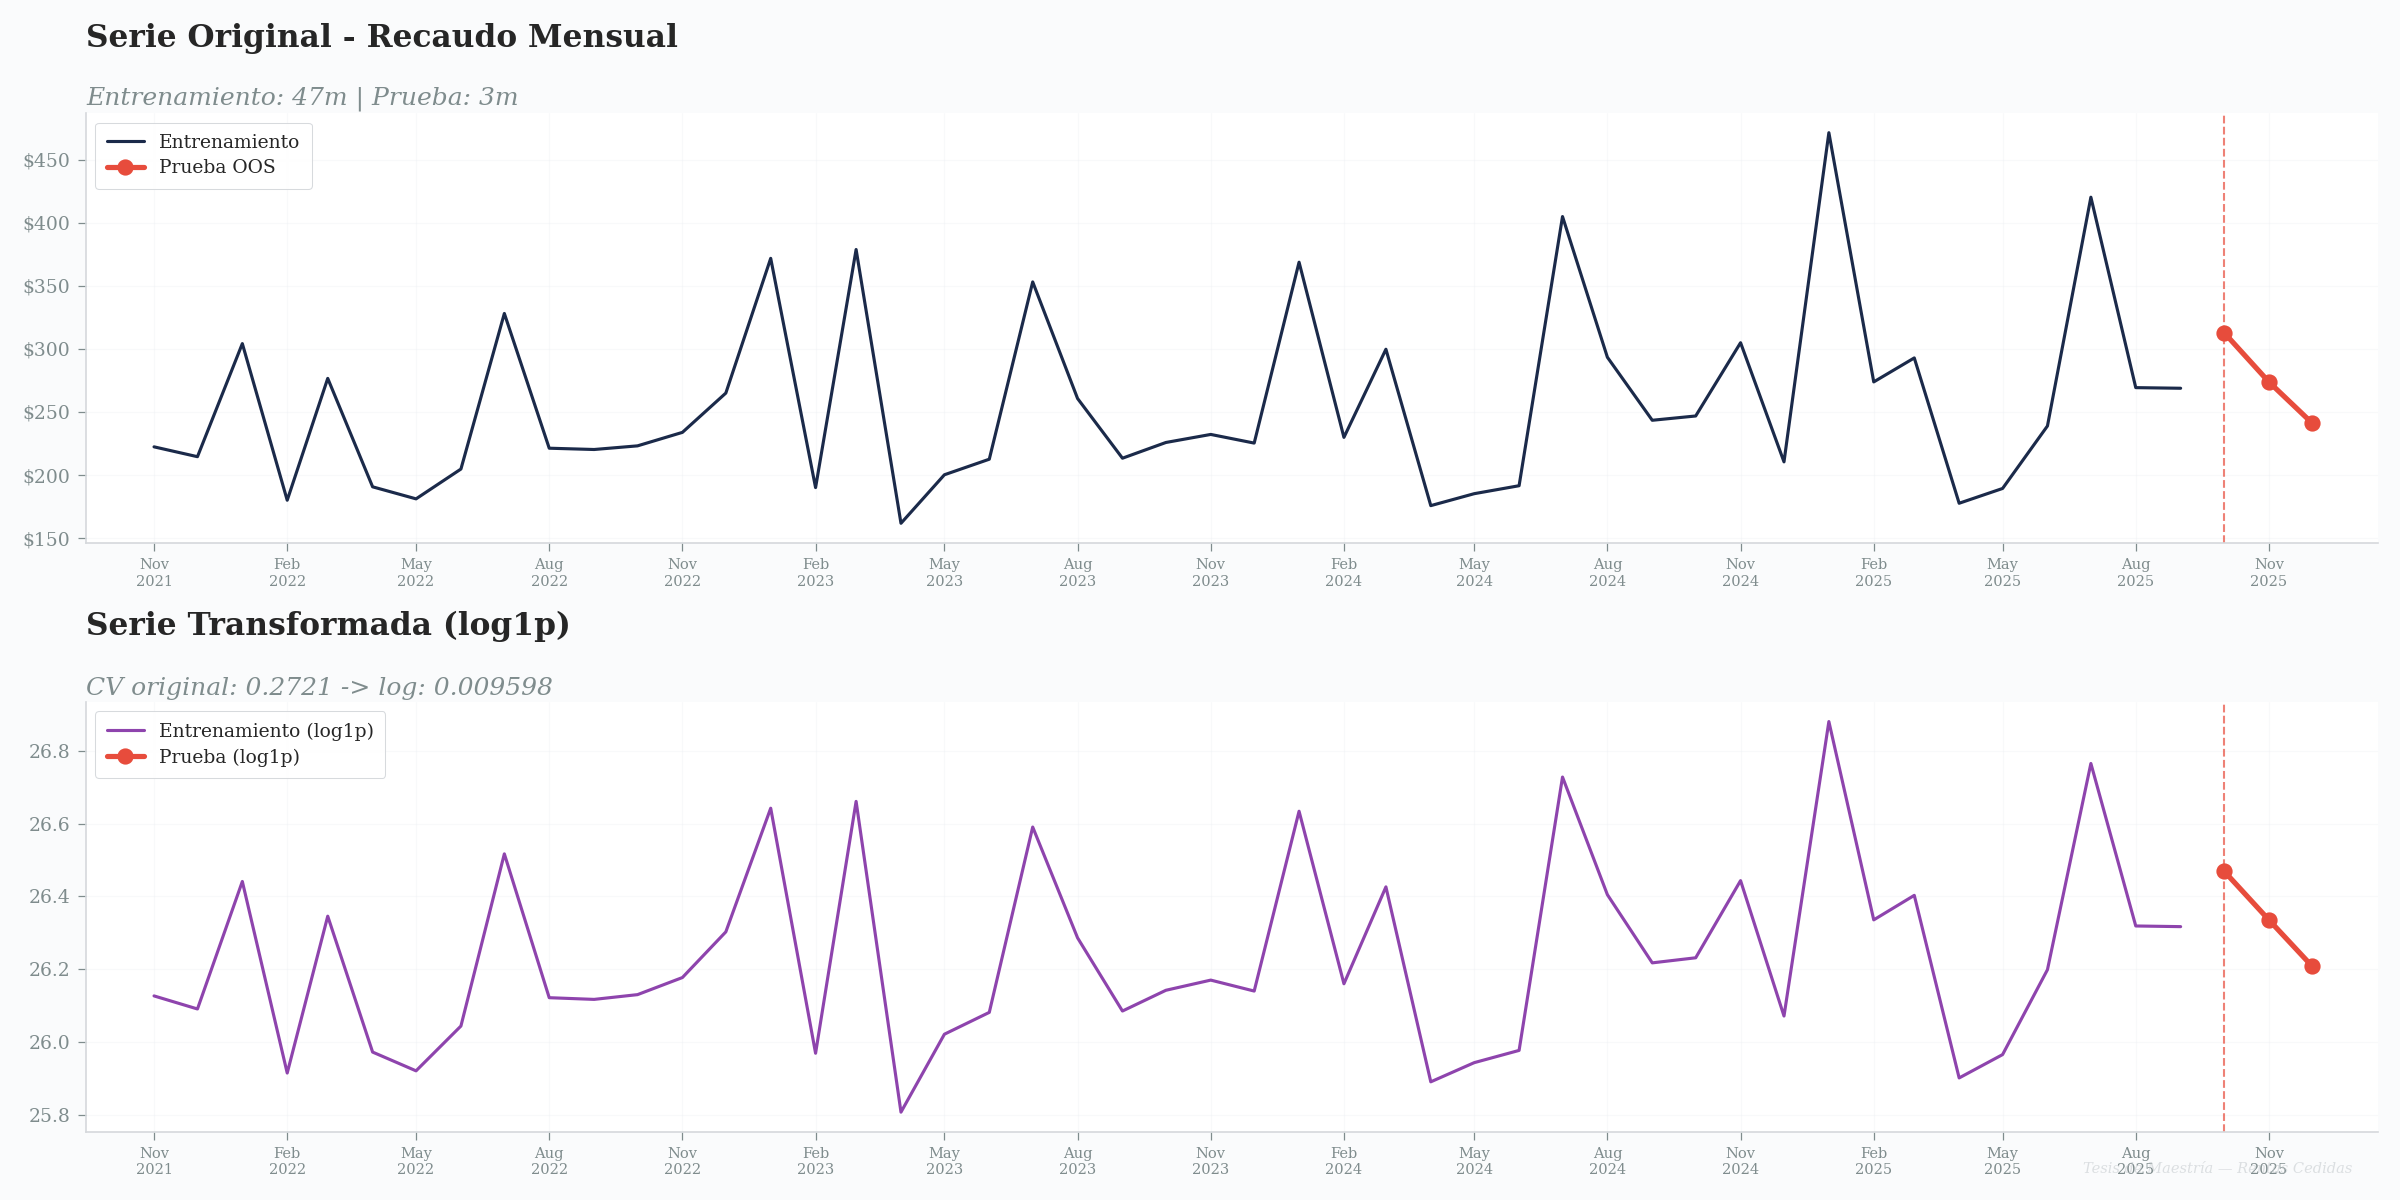

In [2]:
# ══════════════════════════════════════════════════════════════
# FASE I — CARGA, PREPROCESAMIENTO Y NORMALIZACION
# ══════════════════════════════════════════════════════════════

# -- Carga de datos --
csv_serie = DATA_PROCESSED / 'serie_mensual.csv'
csv_macro = DATA_PROCESSED / 'serie_mensual_macro.csv'

df_serie = pd.read_csv(csv_serie, parse_dates=['Fecha'], index_col='Fecha')
df_macro = pd.read_csv(csv_macro, parse_dates=['Fecha'], index_col='Fecha')
df_serie.index.freq = 'MS'
df_macro.index.freq = 'MS'

# Serie: Oct 2021 - Dic 2025 (51 meses)
serie_full = df_serie['Recaudo_Total'].loc[FECHA_INICIO:FECHA_FIN].copy()

# -- Variables exogenas seleccionadas --
# IPC_Idx: indice de precios acumulado (deflactor)
# Consumo_Hogares: proxy de consumo sectorial (licores, juegos de azar)
# UPC: Unidad de Pago por Capitacion (costo de salud, impacta margen fiscal)
# SMLV_COP: salario minimo en pesos (proxy de capacidad adquisitiva)
EXOG_VARS = ['IPC_Idx', 'Consumo_Hogares', 'UPC', 'SMLV_COP']
df_exog = df_macro[EXOG_VARS].loc[FECHA_INICIO:FECHA_FIN].copy()

# -- Transformacion log1p del objetivo --
serie_log = np.log1p(serie_full)

# -- Crear DataFrame consolidado --
df_model = pd.DataFrame(index=serie_full.index)
df_model['y_raw'] = serie_full.values
df_model['y_log'] = serie_log.values

# Agregar exogenas
for col in EXOG_VARS:
    df_model[col] = df_exog[col].values

# -- Variable de rezago: Lag_1 --
# El recaudo de enero = materializacion contable del consumo de diciembre
df_model['Lag_1'] = df_model['y_log'].shift(1)

# -- Variables ciclicas de mes --
df_model['Mes_sin'] = np.sin(2 * np.pi * df_model.index.month / 12)
df_model['Mes_cos'] = np.cos(2 * np.pi * df_model.index.month / 12)

# -- Indicador de pico fiscal (Ene=1, Jul=7) --
df_model['Es_Pico'] = df_model.index.month.isin(MESES_PICO).astype(float)

# Eliminar NaN de Lag_1 (pierde 1 fila: Oct 2021)
df_clean = df_model.dropna().copy()

# -- Split Train / Prueba --
train_mask = df_clean.index <= TRAIN_END
test_mask  = (df_clean.index >= TEST_START) & (df_clean.index <= VALIDATION_END)

df_train = df_clean[train_mask].copy()
df_test  = df_clean[test_mask].copy()

# -- Columnas de entrada para la LSTM --
FEATURE_COLS = ['y_log', 'Lag_1'] + EXOG_VARS + ['Mes_sin', 'Mes_cos', 'Es_Pico']
TARGET_COL = 'y_log'

print(f"{'='*70}")
print(f"PREPROCESAMIENTO COMPLETADO")
print(f"{'='*70}")
print(f"  Serie original:     {len(serie_full)} meses ({serie_full.index.min().date()} -> {serie_full.index.max().date()})")
print(f"  Serie efectiva:     {len(df_clean)} meses (tras eliminar NaN de Lag_1)")
print(f"  Entrenamiento:      {len(df_train)} meses ({df_train.index.min().date()} -> {df_train.index.max().date()})")
print(f"  Prueba OOS:         {len(df_test)} meses ({df_test.index.min().date()} -> {df_test.index.max().date()})")
print(f"  Variables entrada:  {len(FEATURE_COLS)}")
for f in FEATURE_COLS:
    print(f"    - {f}")

# -- Normalizacion MinMaxScaler (ajustado SOLO sobre train) --
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Ajustar y transformar train
X_train_scaled = scaler_X.fit_transform(df_train[FEATURE_COLS].values)
y_train_scaled = scaler_y.fit_transform(df_train[[TARGET_COL]].values)

# Transformar test (sin ajustar — evita data leakage)
X_test_scaled = scaler_X.transform(df_test[FEATURE_COLS].values)
y_test_scaled = scaler_y.transform(df_test[[TARGET_COL]].values)

# Consolidar todo para secuenciacion
all_X_scaled = scaler_X.transform(df_clean[FEATURE_COLS].values)
all_y_scaled = scaler_y.transform(df_clean[[TARGET_COL]].values)

print(f"\n  MinMaxScaler ajustado exclusivamente sobre entrenamiento")
print(f"  Rango X train: [{X_train_scaled.min():.4f}, {X_train_scaled.max():.4f}]")
print(f"  Rango y train: [{y_train_scaled.min():.4f}, {y_train_scaled.max():.4f}]")

# -- Visualizacion: Serie + Split --
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Panel 1: Serie original
ax = axes[0]
ax.plot(df_train.index, df_train['y_raw']/1e9, color=C_PRIMARY, lw=1.5,
        label='Entrenamiento')
ax.plot(df_test.index, df_test['y_raw']/1e9, color=C_TEST, lw=2.5,
        marker='o', ms=7, label='Prueba OOS')
ax.axvline(pd.Timestamp(TEST_START), color=C_TEST, ls='--', lw=1, alpha=0.7)
ax.set_xlim(pd.Timestamp('2021-09-15'), pd.Timestamp('2026-01-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=7); ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Serie Original - Recaudo Mensual',
                       f'Entrenamiento: {len(df_train)}m | Prueba: {len(df_test)}m')
    formato_pesos_eje(ax, eje='y')
    leyenda_profesional(ax, loc='upper left')
else:
    ax.set_title('Serie Original', fontweight='bold')
    ax.legend()

# Panel 2: Serie log1p
ax = axes[1]
ax.plot(df_train.index, df_train['y_log'], color=C_SENARY, lw=1.5,
        label='Entrenamiento (log1p)')
ax.plot(df_test.index, df_test['y_log'], color=C_TEST, lw=2.5,
        marker='o', ms=7, label='Prueba (log1p)')
ax.axvline(pd.Timestamp(TEST_START), color=C_TEST, ls='--', lw=1, alpha=0.7)
ax.set_xlim(pd.Timestamp('2021-09-15'), pd.Timestamp('2026-01-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=7); ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Serie Transformada (log1p)',
                       f'CV original: {serie_full.std()/serie_full.mean():.4f} -> log: {serie_log.std()/serie_log.mean():.6f}')
    leyenda_profesional(ax, loc='upper left')
else:
    ax.set_title('Serie log1p', fontweight='bold')
    ax.legend()

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '08_lstm_serie_split', OUTPUTS_FIGURES)
plt.show()


---

## Fase II — Construcción de Ventanas Temporales (Look-Back)

### Electrocardiograma Fiscal

La configuración de la ventana temporal (`look_back = 12 meses`) se fundamenta
en la **hipótesis de estacionalidad anual** validada en el notebook 02:

- El patrón de recaudo es reproducible cada 12 meses, con picos en
  **enero** (materialización del consumo navideño de licores y juegos) y
  **julio** (segundo ciclo de recaudación semestral).
- Una ventana de 12 meses permite a la red "ver" exactamente un ciclo completo
  antes de predecir el siguiente valor.

### Estructura de las Ventanas

Para cada paso temporal $t$, la entrada de la LSTM es una secuencia
$\mathbf{X}_{t-12:t-1}$ de dimensión $(12 \times F)$ donde $F$ es el número
de variables:

$$\mathbf{X}_t = \begin{bmatrix} x_{t-12,1} & x_{t-12,2} & \cdots & x_{t-12,F} \\ x_{t-11,1} & x_{t-11,2} & \cdots & x_{t-11,F} \\ \vdots & \vdots & \ddots & \vdots \\ x_{t-1,1} & x_{t-1,2} & \cdots & x_{t-1,F} \end{bmatrix} \quad \rightarrow \quad y_t$$

La etiqueta $y_t$ es el recaudo log1p normalizado del mes $t$.


In [3]:
# ══════════════════════════════════════════════════════════════
# FASE II — CONSTRUCCION DE VENTANAS TEMPORALES
# ══════════════════════════════════════════════════════════════

LOOK_BACK = 12  # Ventana = 1 ciclo estacional completo

def crear_ventanas(X_data, y_data, look_back):
    # Crea secuencias 3D (samples, timesteps, features)
    X_seq, y_seq = [], []
    for i in range(look_back, len(X_data)):
        X_seq.append(X_data[i - look_back:i])
        y_seq.append(y_data[i])
    return np.array(X_seq), np.array(y_seq)

# -- Secuenciar todo el dataset limpio --
# Las ultimas 3 ventanas corresponden a Oct-Dic 2025 (prueba)
X_all_seq, y_all_seq = crear_ventanas(all_X_scaled, all_y_scaled, LOOK_BACK)

# Las fechas de las etiquetas corresponden a df_clean.index[LOOK_BACK:]
fechas_seq = df_clean.index[LOOK_BACK:]

# Separar train y test por fecha
train_idx = fechas_seq <= pd.Timestamp(TRAIN_END)
test_idx  = (fechas_seq >= pd.Timestamp(TEST_START)) & (fechas_seq <= pd.Timestamp(VALIDATION_END))

X_train_seq = X_all_seq[train_idx]
y_train_seq = y_all_seq[train_idx]
X_test_seq  = X_all_seq[test_idx]
y_test_seq  = y_all_seq[test_idx]

n_features = X_train_seq.shape[2]

print(f"{'='*70}")
print(f"VENTANAS TEMPORALES CREADAS (look_back = {LOOK_BACK} meses)")
print(f"{'='*70}")
print(f"  Forma X_entrenamiento: {X_train_seq.shape}  ->  (muestras, pasos, variables)")
print(f"  Forma y_entrenamiento: {y_train_seq.shape}")
print(f"  Forma X_prueba:        {X_test_seq.shape}")
print(f"  Forma y_prueba:        {y_test_seq.shape}")
print(f"  Variables por paso:    {n_features}")
print(f"\n  Muestras entrenamiento: {len(X_train_seq)}")
print(f"  Muestras prueba:        {len(X_test_seq)}")
print(f"\n  -> Con {len(X_train_seq)} muestras de entrenamiento, la arquitectura")
print(f"    debe ser ULTRALIGERA para evitar sobreajuste.")


VENTANAS TEMPORALES CREADAS (look_back = 12 meses)
  Forma X_entrenamiento: (35, 12, 9)  ->  (muestras, pasos, variables)
  Forma y_entrenamiento: (35, 1)
  Forma X_prueba:        (3, 12, 9)
  Forma y_prueba:        (3, 1)
  Variables por paso:    9

  Muestras entrenamiento: 35
  Muestras prueba:        3

  -> Con 35 muestras de entrenamiento, la arquitectura
    debe ser ULTRALIGERA para evitar sobreajuste.


---

## Fase III — Arquitectura de la Red LSTM

### Diseño de la Red

Dada la severa escasez de datos ($n_{train}$ < 40 muestras efectivas), se
implementa una arquitectura **ultraligera** con regularización agresiva:

| Capa | Tipo | Unidades | Parámetros |
|------|------|----------|------------|
| 1 | Input | — | `(12, F)` |
| 2 | LSTM | 64 | `return_sequences=True` |
| 3 | Dropout | — | rate = 0.2 |
| 4 | LSTM | 32 | `return_sequences=False` |
| 5 | Dropout | — | rate = 0.2 |
| 6 | Dense | 16 | activación = ReLU |
| 7 | Dense | 1 | activación = linear |

### Protocolo de Regularización

- **Dropout (0.2)**: Desactiva aleatoriamente el 20% de neuronas en cada paso
  de entrenamiento, forzando redundancia en la representación interna.
- **Early Stopping** (patience=30): Monitorea `val_loss`; detiene el
  entrenamiento si no mejora en 30 épocas consecutivas. Restaura los pesos
  del mejor modelo encontrado.
- **ReduceLROnPlateau** (patience=15, factor=0.5): Reduce la tasa de
  aprendizaje a la mitad si el error de validación se estanca.
- **Regularización L2** ($\lambda = 0.001$): Penaliza los pesos grandes para
  prevenir sobreajuste, especialmente crítico con pocas muestras.
- **Entrenamiento determinístico**: Semilla fija en TF, NumPy y Python para
  reproducibilidad total.


ARQUITECTURA LSTM - Red Neuronal Recurrente


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)


  Parametros totales:    31,905
  Muestras entrenamiento: 35
  Ratio muestras/params:  0.0011
  ADVERTENCIA: Ratio < 1 - alto riesgo de sobreajuste
    -> Regularizacion critica: Dropout + L2 + Early Stopping

______________________________________________________________________
ENTRENAMIENTO EN CURSO...
______________________________________________________________________

Epoch 68: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 83: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 83: early stopping
Restoring model weights from the end of the best epoch: 53.

ENTRENAMIENTO COMPLETADO
  Epocas ejecutadas:     83 / 500
  Mejor epoca:           53
  Loss final (train):    0.051474
  Loss final (val):      0.102379
  Loss mejor (val):      0.079851
  MAE final (train):     0.146488
  MAE final (val):       0.257611
  Tiempo:                8.7 seg
  📊 Figura guardada: 08_lstm_curvas_aprendizaje.png


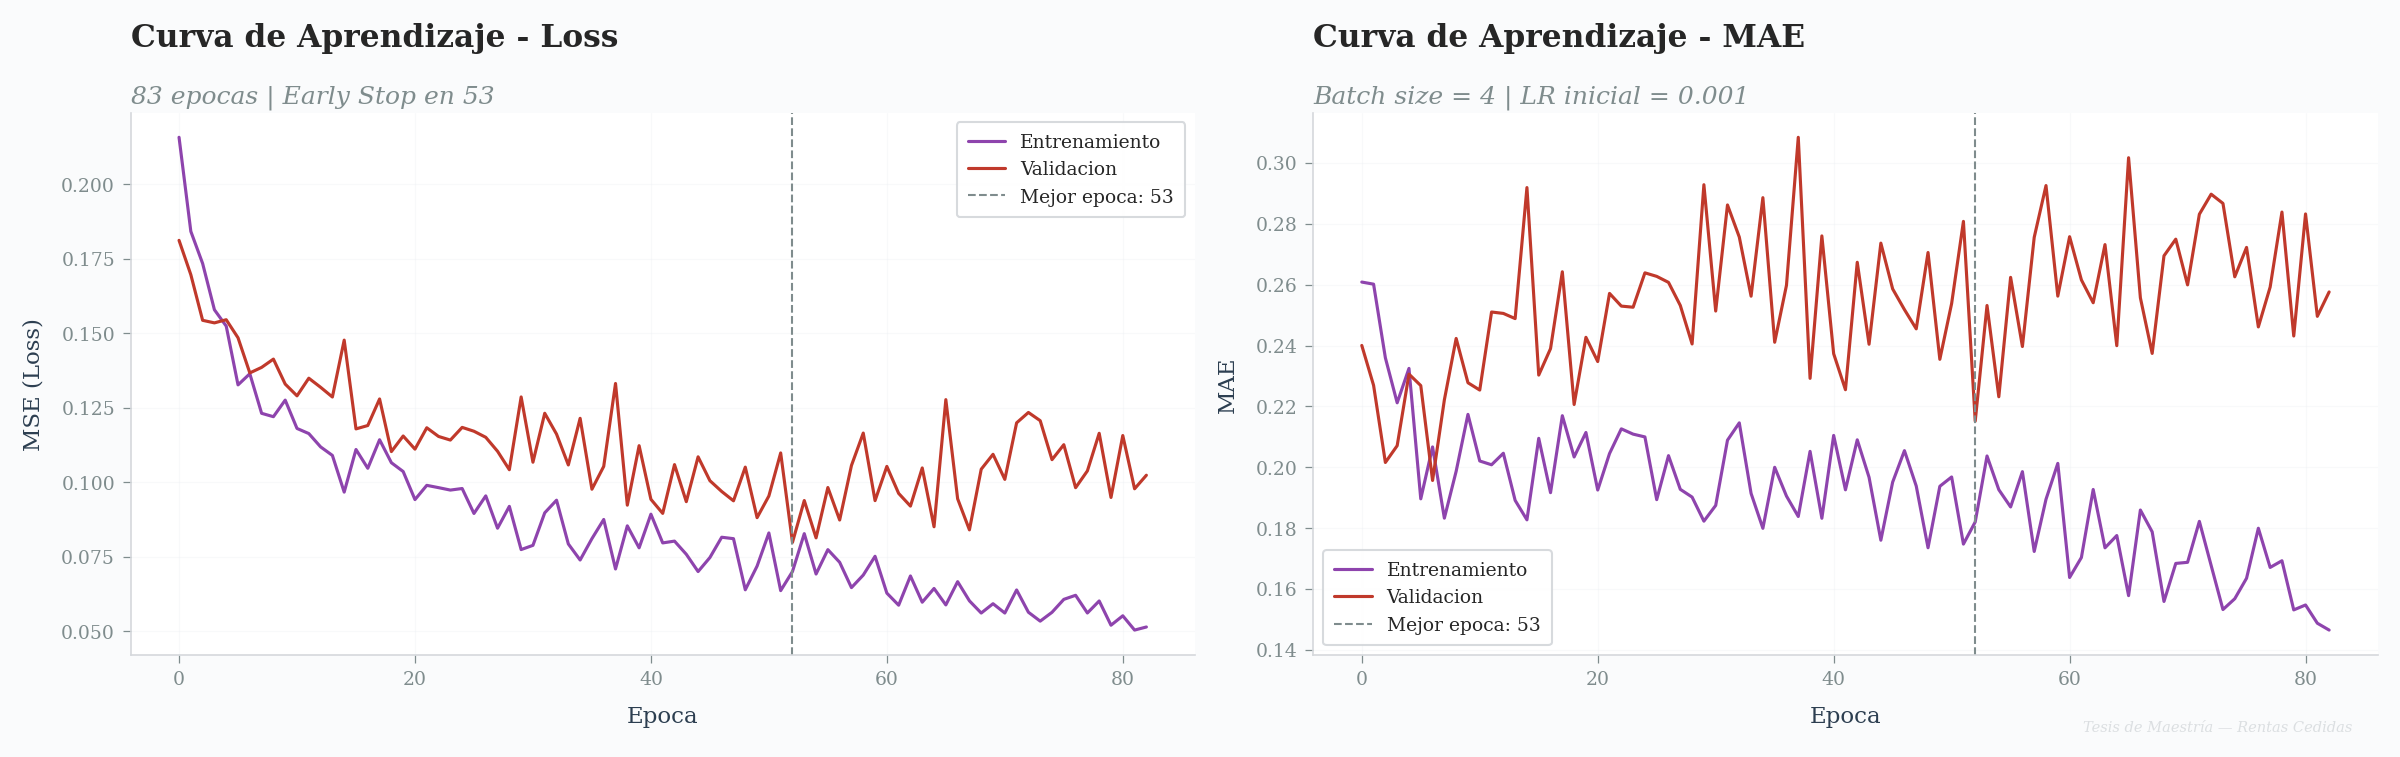

In [4]:
# ══════════════════════════════════════════════════════════════
# FASE III — ARQUITECTURA LSTM Y ENTRENAMIENTO
# ══════════════════════════════════════════════════════════════

# -- Construccion del modelo --
model = Sequential([
    Input(shape=(LOOK_BACK, n_features)),

    # Capa LSTM 1: captura dependencias a largo plazo
    LSTM(64, return_sequences=True,
         kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.2),

    # Capa LSTM 2: refina la representacion
    LSTM(32, return_sequences=False,
         kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.2),

    # Capas densas de salida
    Dense(16, activation='relu'),
    Dense(1, activation='linear'),
])

# -- Compilar --
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# -- Resumen de arquitectura --
print(f"{'='*70}")
print(f"ARQUITECTURA LSTM - Red Neuronal Recurrente")
print(f"{'='*70}")
model.summary()

n_params = model.count_params()
ratio = len(X_train_seq) / n_params
print(f"\n  Parametros totales:    {n_params:,}")
print(f"  Muestras entrenamiento: {len(X_train_seq)}")
print(f"  Ratio muestras/params:  {ratio:.4f}")
if ratio < 1:
    print(f"  ADVERTENCIA: Ratio < 1 - alto riesgo de sobreajuste")
    print(f"    -> Regularizacion critica: Dropout + L2 + Early Stopping")
else:
    print(f"  Ratio aceptable para redes neuronales")

# -- Callbacks --
early_stop = EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True,
    verbose=1, mode='min'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', patience=15, factor=0.5,
    min_lr=1e-6, verbose=1, mode='min'
)

# -- Entrenamiento --
# Usamos 15% del train como validacion interna para Early Stopping
print(f"\n{'_'*70}")
print(f"ENTRENAMIENTO EN CURSO...")
print(f"{'_'*70}")

t0 = time.time()

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=500,
    batch_size=4,           # Lotes pequenos (pocas muestras)
    validation_split=0.15,  # ~5 muestras como validacion interna
    callbacks=[early_stop, reduce_lr],
    verbose=0,
    shuffle=False,          # No mezclar - respetar orden temporal
)

elapsed = time.time() - t0
best_epoch = np.argmin(history.history['val_loss']) + 1
n_epochs = len(history.history['loss'])

print(f"\n{'='*70}")
print(f"ENTRENAMIENTO COMPLETADO")
print(f"{'='*70}")
print(f"  Epocas ejecutadas:     {n_epochs} / 500")
print(f"  Mejor epoca:           {best_epoch}")
print(f"  Loss final (train):    {history.history['loss'][-1]:.6f}")
print(f"  Loss final (val):      {history.history['val_loss'][-1]:.6f}")
print(f"  Loss mejor (val):      {min(history.history['val_loss']):.6f}")
print(f"  MAE final (train):     {history.history['mae'][-1]:.6f}")
print(f"  MAE final (val):       {history.history['val_mae'][-1]:.6f}")
print(f"  Tiempo:                {elapsed:.1f} seg")

# -- Curvas de aprendizaje --
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Loss
ax = axes[0]
ax.plot(history.history['loss'], color=C_SENARY, lw=1.5, label='Entrenamiento')
ax.plot(history.history['val_loss'], color=C_SECONDARY, lw=1.5, label='Validacion')
ax.axvline(best_epoch - 1, color=C_TEXT_LIGHT, ls='--', lw=1,
           label=f'Mejor epoca: {best_epoch}')
ax.set_xlabel('Epoca', fontsize=11)
ax.set_ylabel('MSE (Loss)', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Curva de Aprendizaje - Loss',
                       f'{n_epochs} epocas | Early Stop en {best_epoch}')
else:
    ax.set_title('Curva de Aprendizaje - Loss', fontweight='bold')

# Panel 2: MAE
ax = axes[1]
ax.plot(history.history['mae'], color=C_SENARY, lw=1.5, label='Entrenamiento')
ax.plot(history.history['val_mae'], color=C_SECONDARY, lw=1.5, label='Validacion')
ax.axvline(best_epoch - 1, color=C_TEXT_LIGHT, ls='--', lw=1,
           label=f'Mejor epoca: {best_epoch}')
ax.set_xlabel('Epoca', fontsize=11)
ax.set_ylabel('MAE', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Curva de Aprendizaje - MAE',
                       f'Batch size = 4 | LR inicial = 0.001')
else:
    ax.set_title('Curva de Aprendizaje - MAE', fontweight='bold')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '08_lstm_curvas_aprendizaje', OUTPUTS_FIGURES)
plt.show()


---

## Fase IV — Pronóstico Out-of-Sample (Oct–Dic 2025)

Se evalúa la capacidad predictiva del modelo LSTM sobre los **últimos 3 meses**
del dataset (conjunto de prueba inamovible), comparando directamente con los
valores reales observados.

### Proceso de Retransformación

Los pronósticos se generan en espacio normalizado $[0,1]$ y se retransforman
mediante la cadena inversa:

$$\hat{y}_{pesos} = \text{expm1}\left(\text{scaler\_y}^{-1}(\hat{y}_{norm})\right)$$


PRONOSTICO OUT-OF-SAMPLE - LSTM
  Periodo: Oct 2025 -> Dic 2025 (3 meses)

______________________________________________________________________
METRICAS DE EVALUACION:
______________________________________________________________________
  MAPE:      23.52%
  RMSE:      $73.5 MM COP
  MAE:       $59.6 MM COP
  MAE rel:   21.6% de la media de la prueba

______________________________________________________________________
Mes                     Real      Pronostico        Error   Error%
______________________________________________________________________
  2025-10    $        313.0MM  $        318.1MM  $       5.1MM     1.6%
  2025-11    $        273.8MM  $        337.2MM  $      63.4MM    23.2%
  2025-12    $        241.0MM  $        351.4MM  $     110.3MM    45.8%

  Bootstrap IC 95% calculado (200 iteraciones, residuos)
    2025-10: [151.6, 400.6] MM
    2025-11: [175.9, 423.4] MM
    2025-12: [190.0, 437.5] MM
  📊 Figura guardada: 08_lstm_oos_validacion.png


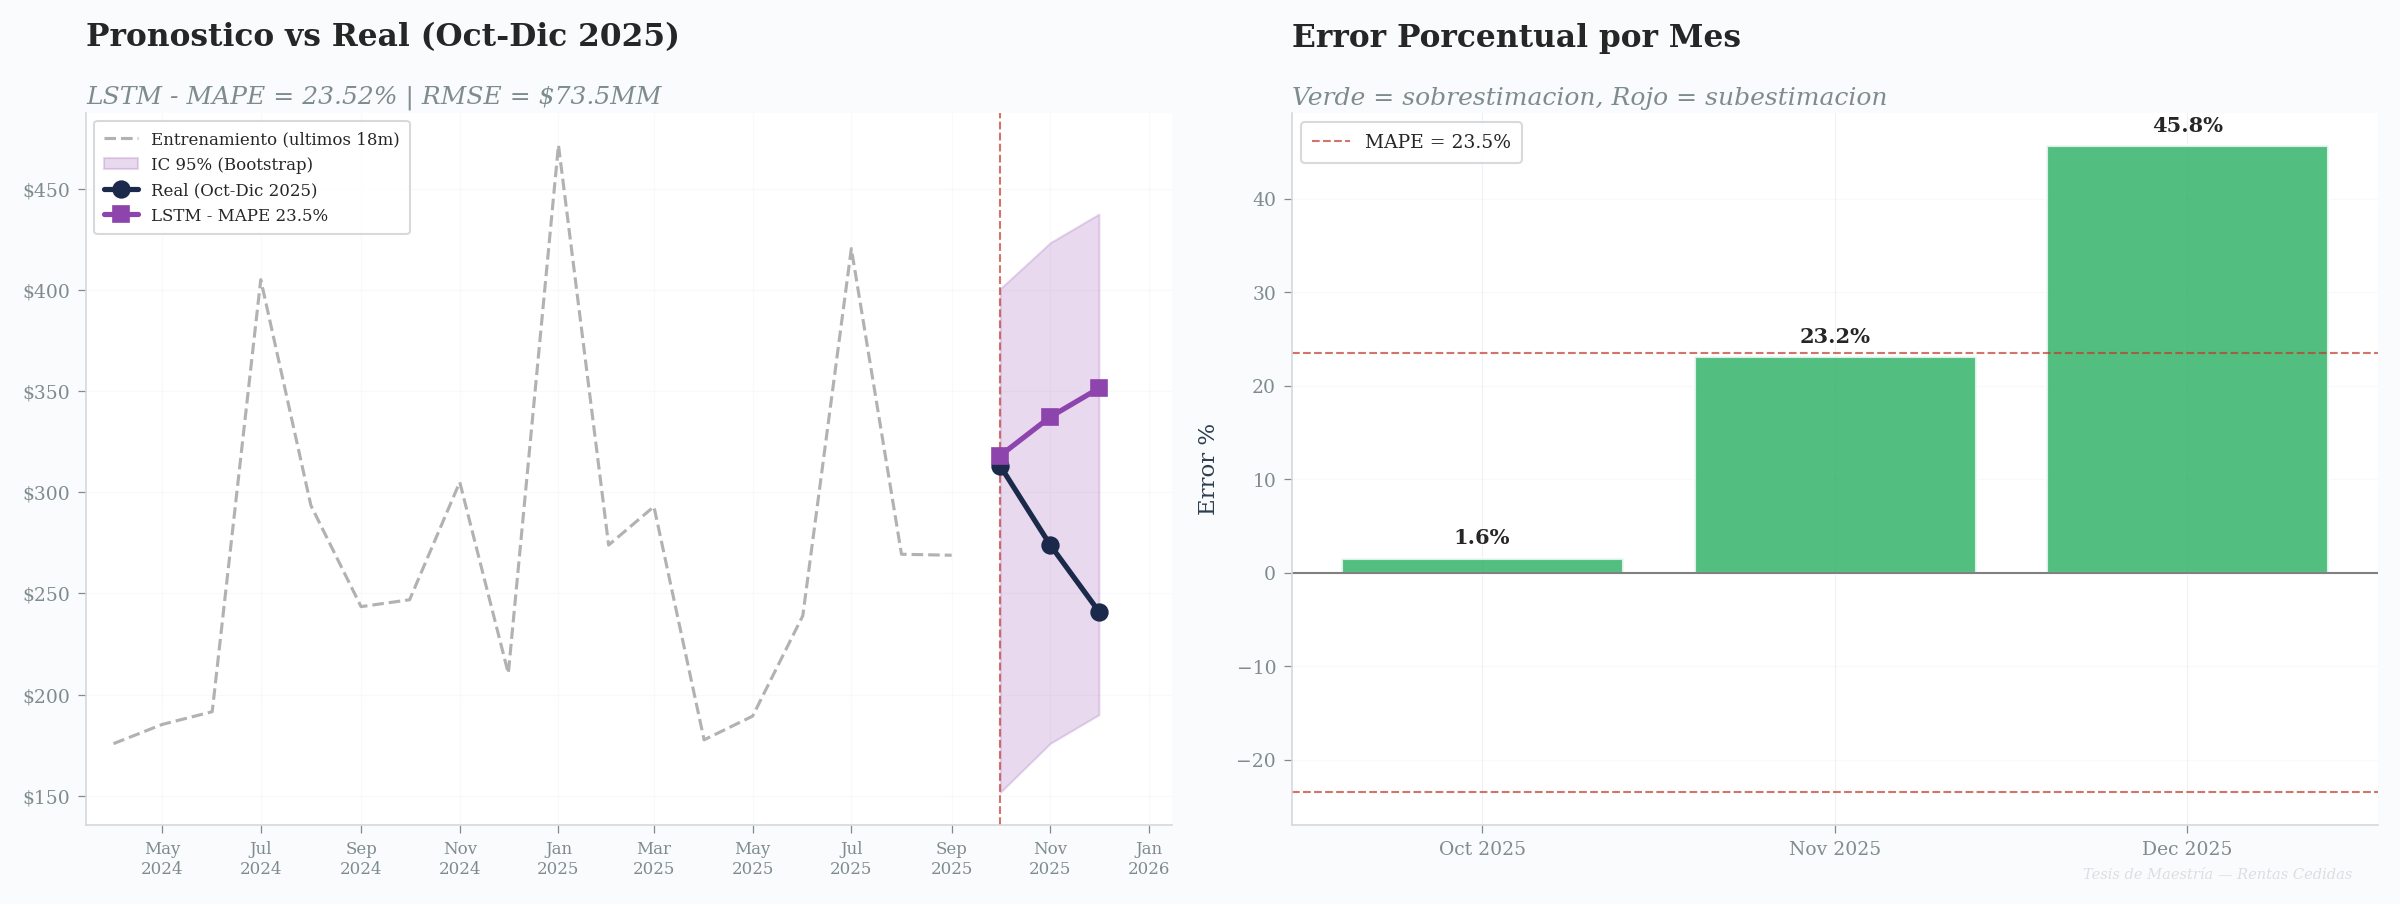


  Pronostico OOS guardado: lstm_forecast.csv


In [5]:
# ══════════════════════════════════════════════════════════════
# FASE IV — PRONOSTICO OUT-OF-SAMPLE (Oct-Dic 2025)
# ══════════════════════════════════════════════════════════════

# -- Prediccion sobre el conjunto de prueba --
y_pred_scaled = model.predict(X_test_seq, verbose=0)

# -- Retransformacion: normalizado -> log1p -> pesos --
y_pred_log = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_log = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Retransformar de log1p a pesos colombianos
y_pred_pesos = np.expm1(y_pred_log)
y_real_pesos = np.expm1(y_test_log)

# -- Metricas de evaluacion --
mape = mean_absolute_percentage_error(y_real_pesos, y_pred_pesos) * 100
rmse = np.sqrt(mean_squared_error(y_real_pesos, y_pred_pesos))
mae  = mean_absolute_error(y_real_pesos, y_pred_pesos)
mae_rel = mae / np.mean(y_real_pesos) * 100

print(f"{'='*70}")
print(f"PRONOSTICO OUT-OF-SAMPLE - LSTM")
print(f"{'='*70}")
print(f"  Periodo: Oct 2025 -> Dic 2025 ({len(y_real_pesos)} meses)")
print(f"\n{'_'*70}")
print(f"METRICAS DE EVALUACION:")
print(f"{'_'*70}")
print(f"  MAPE:      {mape:.2f}%")
print(f"  RMSE:      ${rmse/1e9:,.1f} MM COP")
print(f"  MAE:       ${mae/1e9:,.1f} MM COP")
print(f"  MAE rel:   {mae_rel:.1f}% de la media de la prueba")

# -- Detalle mes a mes --
fechas_test = fechas_seq[test_idx]
print(f"\n{'_'*70}")
print(f"{'Mes':<12} {'Real':>15} {'Pronostico':>15} {'Error':>12} {'Error%':>8}")
print(f"{'_'*70}")
for i, fecha in enumerate(fechas_test):
    real = y_real_pesos[i]
    pred = y_pred_pesos[i]
    err  = pred - real
    err_pct = (pred - real) / real * 100
    print(f"  {fecha.strftime('%Y-%m'):<10} ${real/1e9:>13,.1f}MM  ${pred/1e9:>13,.1f}MM  "
          f"${err/1e9:>10,.1f}MM  {err_pct:>6.1f}%")

# -- Prediccion sobre entrenamiento (para visualizacion y bootstrap CI) --
y_train_pred_scaled = model.predict(X_train_seq, verbose=0)
y_train_pred_log = scaler_y.inverse_transform(y_train_pred_scaled).flatten()
y_train_pred_pesos = np.expm1(y_train_pred_log)
y_train_real_pesos = np.expm1(
    scaler_y.inverse_transform(y_train_seq.reshape(-1, 1)).flatten()
)

# -- Bootstrap Residuos: Intervalo de Confianza 95% --
residuos_train = y_train_pred_pesos - y_train_real_pesos
N_BOOT = 200
rng_boot = np.random.RandomState(SEED)
preds_boot = np.zeros((N_BOOT, len(y_pred_pesos)))
for b in range(N_BOOT):
    resample = rng_boot.choice(residuos_train, size=len(y_pred_pesos), replace=True)
    preds_boot[b] = y_pred_pesos + resample

ci_lower = np.percentile(preds_boot, 2.5, axis=0)
ci_upper = np.percentile(preds_boot, 97.5, axis=0)

print(f"\n  Bootstrap IC 95% calculado ({N_BOOT} iteraciones, residuos)")
for i, fecha in enumerate(fechas_test):
    print(f"    {fecha.strftime('%Y-%m')}: [{ci_lower[i]/1e9:.1f}, {ci_upper[i]/1e9:.1f}] MM")

# -- Visualizacion completa --
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Contexto historico + OOS
ax = axes[0]
train_dates = fechas_seq[train_idx]
n_hist = min(18, len(train_dates))
ax.plot(train_dates[-n_hist:], y_train_real_pesos[-n_hist:]/1e9,
        color='grey', lw=1.5, ls='--', alpha=0.6, label='Entrenamiento (ultimos 18m)')
ax.fill_between(fechas_test, ci_lower/1e9, ci_upper/1e9,
                color=C_SENARY, alpha=0.2, label='IC 95% (Bootstrap)')
ax.plot(fechas_test, y_real_pesos/1e9, color=C_PRIMARY, lw=2.5,
        marker='o', markersize=8, label='Real (Oct-Dic 2025)', zorder=5)
ax.plot(fechas_test, y_pred_pesos/1e9, color=C_SENARY, lw=2.5,
        marker='s', markersize=8, label=f'LSTM - MAPE {mape:.1f}%', zorder=5)
ax.axvline(pd.Timestamp(TEST_START), color=C_SECONDARY, ls='--', lw=1, alpha=0.7)
ax.set_xlim(pd.Timestamp('2024-03-15'), pd.Timestamp('2026-01-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=8)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='upper left')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Pronostico vs Real (Oct-Dic 2025)',
                       f'LSTM - MAPE = {mape:.2f}% | RMSE = ${rmse/1e9:.1f}MM')
    formato_pesos_eje(ax, eje='y')
else:
    ax.set_title(f'LSTM - Validacion OOS (MAPE={mape:.2f}%)',
                 fontsize=12, fontweight='bold')

# Panel 2: Barras de error porcentual
ax2 = axes[1]
meses_label = [f.strftime('%b %Y') for f in fechas_test]
errores_pct = [(y_pred_pesos[k] - y_real_pesos[k]) / y_real_pesos[k] * 100
               for k in range(len(y_real_pesos))]
colors_bar = [C_POSITIVE if e >= 0 else C_NEGATIVE for e in errores_pct]
ax2.bar(meses_label, errores_pct, color=colors_bar, alpha=0.8,
        edgecolor='white', lw=1.5)
ax2.axhline(0, color='grey', lw=1)
ax2.axhline(mape, color=C_SECONDARY, ls='--', lw=1, alpha=0.7,
            label=f'MAPE = {mape:.1f}%')
ax2.axhline(-mape, color=C_SECONDARY, ls='--', lw=1, alpha=0.7)
for k, (m, e) in enumerate(zip(meses_label, errores_pct)):
    offset = 1.5 if e >= 0 else -3
    ax2.text(k, e + offset, f'{e:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylabel('Error %', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend(fontsize=9)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax2, 'Error Porcentual por Mes',
                       'Verde = sobrestimacion, Rojo = subestimacion')
else:
    ax2.set_title('Error % por Mes', fontsize=12, fontweight='bold')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '08_lstm_oos_validacion', OUTPUTS_FIGURES)
plt.show()

# -- Guardar pronostico OOS --
df_oos = pd.DataFrame({
    'Fecha': fechas_test,
    'Real': y_real_pesos,
    'Pronostico_LSTM': y_pred_pesos,
    'IC_Inferior': ci_lower,
    'IC_Superior': ci_upper,
    'Error_Abs': np.abs(y_pred_pesos - y_real_pesos),
    'Error_Pct': (y_pred_pesos - y_real_pesos) / y_real_pesos * 100
})
df_oos.to_csv(OUTPUTS_FORECASTS / 'lstm_forecast.csv', index=False)
print(f"\n  Pronostico OOS guardado: lstm_forecast.csv")

---

## Fase V — Diagnóstico de Residuos y Análisis de Error

Se evalúa la calidad estadística de los residuos del modelo LSTM sobre
el conjunto de **entrenamiento** para verificar:

1. **Incorrelación temporal** (Ljung-Box): los residuos no deben tener
   autocorrelación significativa.
2. **Normalidad** (Shapiro-Wilk): los residuos deben aproximarse a una
   distribución normal centrada en cero.
3. **Homocedasticidad**: la varianza de los residuos debe ser constante
   a lo largo del tiempo.

> **Nota:** Con muestras tan reducidas, las pruebas estadísticas tienen
> bajo poder. Se interpretan como indicativos, no como conclusiones definitivas.


DIAGNOSTICO ESTADISTICO DE RESIDUOS - LSTM
  Residuos analizados:    35 (entrenamiento)
  Media:                  0.022365
  Std:                    0.247220

  Ljung-Box (min p):      0.0245  Autocorrelacion detectada
  Shapiro-Wilk p:         0.0375    No normal
  T-test (mu=0) p:        0.6013    Media aprox 0
  Levene (homoced.) p:    0.8120   Homocedastico
  📊 Figura guardada: 08_lstm_diagnostico_residuos.png


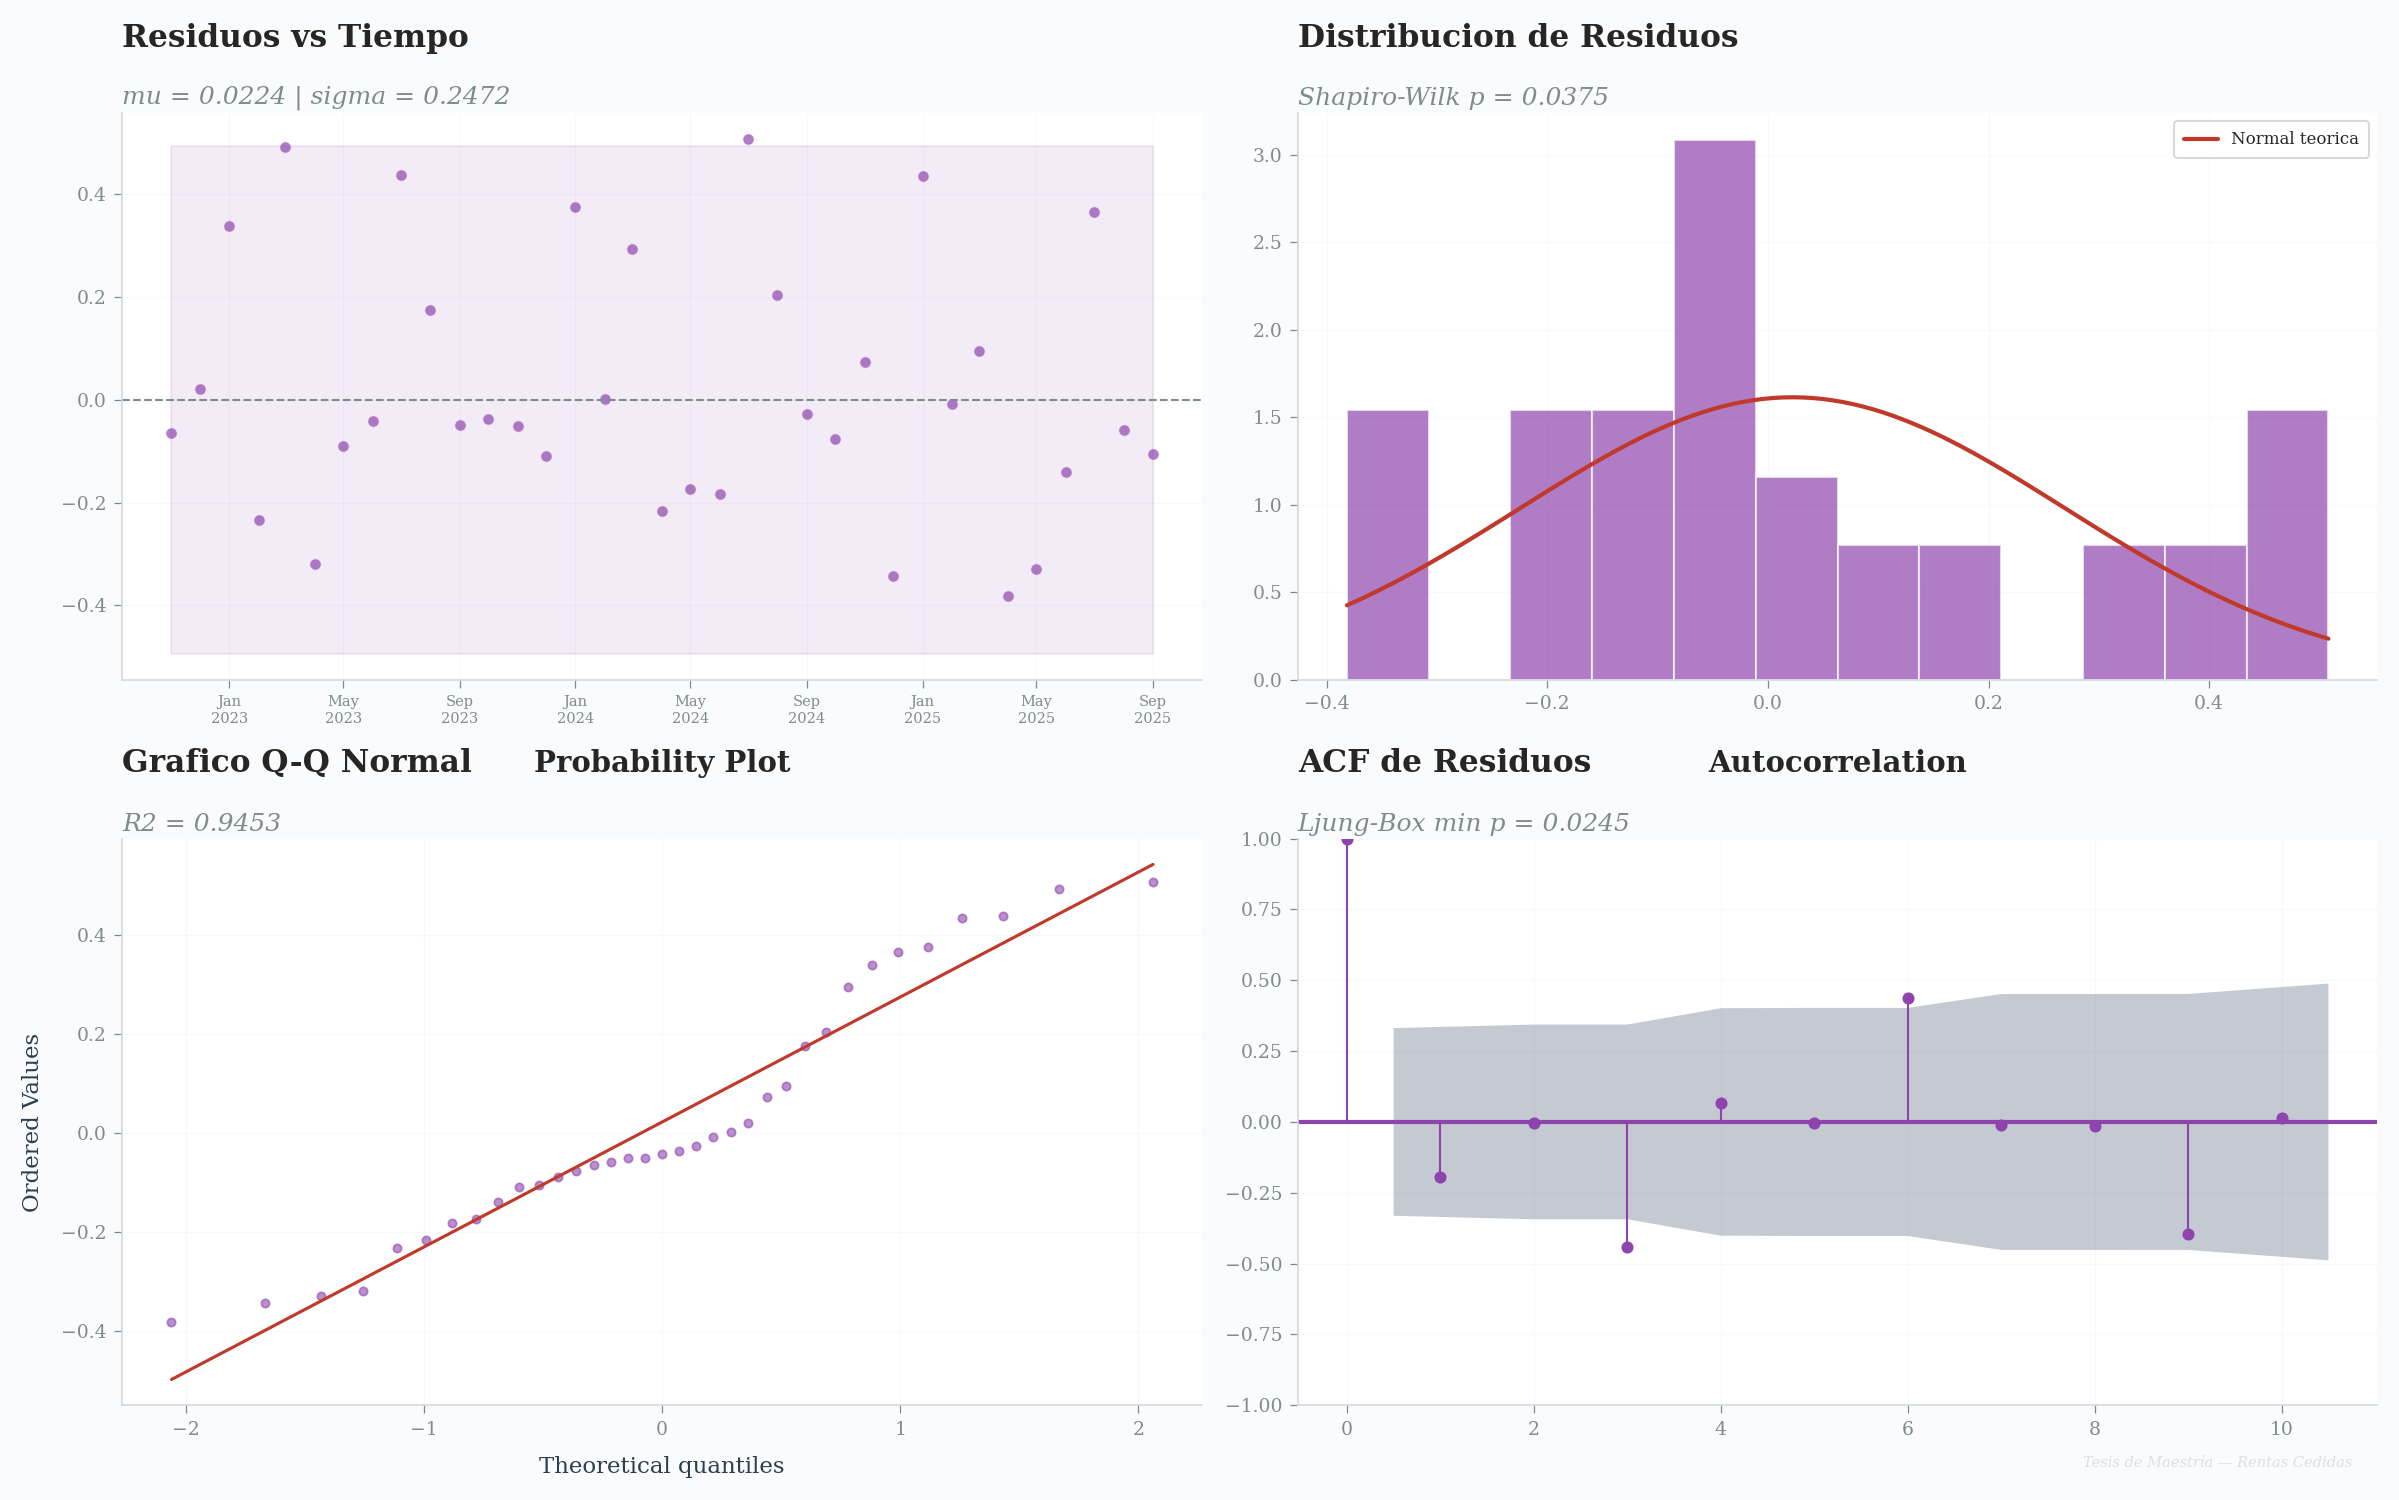


______________________________________________________________________
VEREDICTO: 2/4 pruebas superadas
  -> Modelo ACEPTABLE con reservas (muestra pequena reduce poder de pruebas)


In [6]:
# ══════════════════════════════════════════════════════════════
# FASE V — DIAGNOSTICO DE RESIDUOS
# ══════════════════════════════════════════════════════════════

# Residuos en escala log1p (entrenamiento)
y_train_log_real = scaler_y.inverse_transform(y_train_seq.reshape(-1, 1)).flatten()
y_train_log_pred = scaler_y.inverse_transform(y_train_pred_scaled).flatten()
residuos = y_train_log_real - y_train_log_pred

# -- Pruebas estadisticas --
# Ljung-Box
n_lags_lb = min(5, len(residuos) // 3)
if n_lags_lb >= 1:
    lb_result = acorr_ljungbox(residuos, lags=n_lags_lb, return_df=True)
    lb_min_p = lb_result['lb_pvalue'].min()
else:
    lb_min_p = np.nan

# Shapiro-Wilk
sw_stat, sw_p = stats.shapiro(residuos)

# Media cero
t_stat, t_p = stats.ttest_1samp(residuos, 0)

# Levene (primera mitad vs segunda mitad)
mid = len(residuos) // 2
lev_stat, lev_p = stats.levene(residuos[:mid], residuos[mid:])

print(f"{'='*70}")
print(f"DIAGNOSTICO ESTADISTICO DE RESIDUOS - LSTM")
print(f"{'='*70}")
print(f"  Residuos analizados:    {len(residuos)} (entrenamiento)")
print(f"  Media:                  {residuos.mean():.6f}")
print(f"  Std:                    {residuos.std():.6f}")
lb_txt = 'Incorrelados' if lb_min_p > 0.05 else 'Autocorrelacion detectada'
sw_txt = 'Normal' if sw_p > 0.05 else 'No normal'
tt_txt = 'Media aprox 0' if t_p > 0.05 else 'Sesgo detectado'
lv_txt = 'Homocedastico' if lev_p > 0.05 else 'Heterocedastico'
print(f"\n  Ljung-Box (min p):      {lb_min_p:.4f}  {lb_txt}")
print(f"  Shapiro-Wilk p:         {sw_p:.4f}    {sw_txt}")
print(f"  T-test (mu=0) p:        {t_p:.4f}    {tt_txt}")
print(f"  Levene (homoced.) p:    {lev_p:.4f}   {lv_txt}")

# -- Visualizacion 2x2 --
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Residuos vs Tiempo
ax = axes[0, 0]
ax.scatter(train_dates, residuos, color=C_SENARY, s=30, alpha=0.7,
           edgecolors='white', linewidth=0.5)
ax.axhline(0, color=C_TEXT_LIGHT, ls='--', lw=1)
ax.fill_between(train_dates, -2*residuos.std(), 2*residuos.std(),
                alpha=0.1, color=C_SENARY)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=7)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Residuos vs Tiempo',
                       f'mu = {residuos.mean():.4f} | sigma = {residuos.std():.4f}')

# Panel 2: Histograma + Normal teorica
ax = axes[0, 1]
ax.hist(residuos, bins=12, color=C_SENARY, edgecolor='white',
        alpha=0.7, density=True)
x_norm = np.linspace(residuos.min(), residuos.max(), 100)
ax.plot(x_norm, stats.norm.pdf(x_norm, residuos.mean(), residuos.std()),
        color=C_SECONDARY, lw=2, label='Normal teorica')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Distribucion de Residuos',
                       f'Shapiro-Wilk p = {sw_p:.4f}')

# Panel 3: Q-Q Plot
ax = axes[1, 0]
res_qq = stats.probplot(residuos, dist='norm', plot=ax)
ax.get_lines()[0].set(color=C_SENARY, markersize=4, alpha=0.6)
ax.get_lines()[1].set(color=C_SECONDARY, linewidth=1.5)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Grafico Q-Q Normal',
                       f'R2 = {res_qq[1][2]**2:.4f}')

# Panel 4: ACF de residuos
ax = axes[1, 1]
n_lags_acf = min(10, len(residuos) // 2 - 1)
if n_lags_acf > 2:
    plot_acf(residuos, ax=ax, lags=n_lags_acf, alpha=0.05,
             color=C_SENARY, vlines_kwargs={'colors': C_SENARY, 'linewidth': 1.0})
    ax.grid(True, alpha=0.3)
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, 'ACF de Residuos',
                           f'Ljung-Box min p = {lb_min_p:.4f}')
else:
    ax.text(0.5, 0.5, 'Muy pocos datos para ACF', transform=ax.transAxes,
            ha='center', va='center', fontsize=12)

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '08_lstm_diagnostico_residuos', OUTPUTS_FIGURES)
plt.show()

# -- Veredicto --
checks = [lb_min_p > 0.05 if not np.isnan(lb_min_p) else False,
          sw_p > 0.05, lev_p > 0.05, t_p > 0.05]
n_pass = sum(checks)
print(f"\n{'_'*70}")
print(f"VEREDICTO: {n_pass}/4 pruebas superadas")
if n_pass >= 3:
    print(f"  -> Modelo ACEPTABLE para pronostico")
elif n_pass >= 2:
    print(f"  -> Modelo ACEPTABLE con reservas (muestra pequena reduce poder de pruebas)")
else:
    print(f"  -> Modelo requiere revision (considerar arquitectura alternativa)")


---

## Fase VI — Comparativa vs Modelos Lineales y ML

Se comparan las métricas OOS del LSTM frente a los modelos evaluados
previamente: SARIMA, SARIMAX, Prophet y XGBoost.

### Expectativa

Dado que el LSTM opera con menos de 40 muestras de entrenamiento efectivas
(insuficientes para redes profundas), se espera que su desempeño sea
**inferior o comparable** a modelos estadísticos parsimoniosos (SARIMA) y de
ensamble (XGBoost). Este resultado es **epistemológicamente valioso**: demuestra
que más complejidad algorítmica no siempre se traduce en mejor pronóstico cuando
$n$ es pequeño (principio de parsimonia de Occam).


COMPARATIVA DE MODELOS - Validacion OOS (Oct-Dic 2025)

Modelo         MAPE %    RMSE (MM)     MAE (MM)
________________________________________________
  XGBoost       5.05%        15.4        13.8 (mejor)
  Prophet       6.30%        28.7        19.3
  SARIMAX      13.99%        42.5        39.6
  SARIMA       13.99%        42.5        39.6
  LSTM         23.52%        73.5        59.6

  Modelo con menor MAPE: XGBoost (5.05%)
  LSTM: posicion 5/5 (MAPE = 23.52%)
  📊 Figura guardada: 08_lstm_comparativa_modelos.png


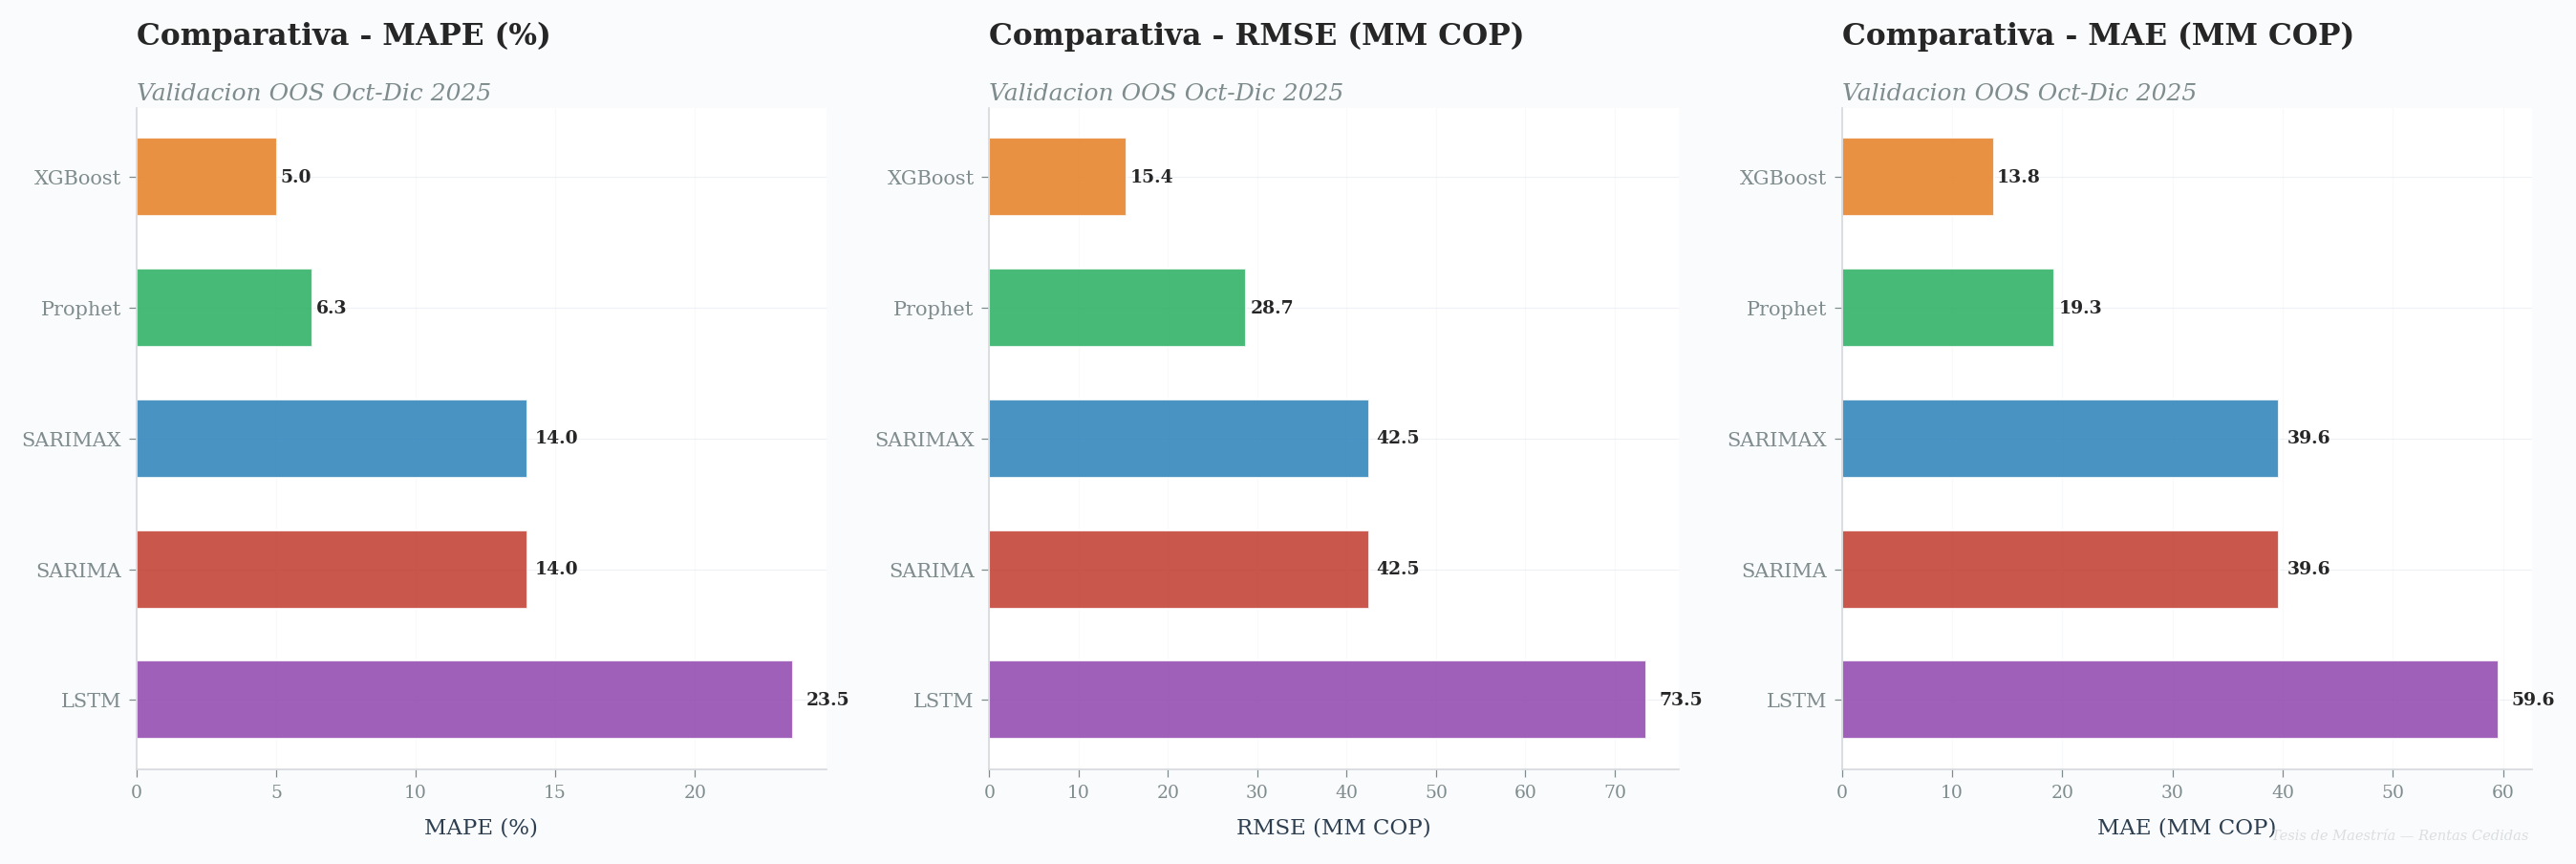


  Comparativa exportada: comparacion_lstm_vs_otros.csv


In [7]:
# ══════════════════════════════════════════════════════════════
# FASE VI — COMPARATIVA VS MODELOS ANTERIORES
# ══════════════════════════════════════════════════════════════

# -- Cargar pronosticos de otros modelos --
modelos_csv = {
    'SARIMA':  'sarima_forecast.csv',
    'SARIMAX': 'sarimax_forecast.csv',
    'Prophet': 'prophet_forecast.csv',
    'XGBoost': 'xgboost_forecast.csv',
}

comparativa = []

# Metricas LSTM
comparativa.append({
    'Modelo': 'LSTM',
    'MAPE_%': round(mape, 2),
    'RMSE_MM': round(rmse / 1e9, 1),
    'MAE_MM': round(mae / 1e9, 1),
    'Color': C_SENARY,
})

for nombre, archivo in modelos_csv.items():
    csv_path = OUTPUTS_FORECASTS / archivo
    if csv_path.exists():
        df_m = pd.read_csv(csv_path)
        if 'Real' in df_m.columns:
            # Diferentes notebooks usan diferentes nombres de columna
            col_pred = [c for c in df_m.columns if 'Pronostico' in c or 'Pred' in c
                        or 'Forecast' in c]
            if col_pred:
                pred_col = col_pred[0]
            else:
                continue

            real_vals = df_m['Real'].values
            pred_vals = df_m[pred_col].values

            m_mape = mean_absolute_percentage_error(real_vals, pred_vals) * 100
            m_rmse = np.sqrt(mean_squared_error(real_vals, pred_vals))
            m_mae  = mean_absolute_error(real_vals, pred_vals)

            color = COLORES_MODELOS.get(nombre.lower(), 'grey')
            comparativa.append({
                'Modelo': nombre,
                'MAPE_%': round(m_mape, 2),
                'RMSE_MM': round(m_rmse / 1e9, 1),
                'MAE_MM': round(m_mae / 1e9, 1),
                'Color': color,
            })

df_comp = pd.DataFrame(comparativa).sort_values('MAPE_%')

print(f"{'='*70}")
print(f"COMPARATIVA DE MODELOS - Validacion OOS (Oct-Dic 2025)")
print(f"{'='*70}")
print(f"\n{'Modelo':<12} {'MAPE %':>8} {'RMSE (MM)':>12} {'MAE (MM)':>12}")
print(f"{'_'*48}")
for _, row in df_comp.iterrows():
    marker = ' (mejor)' if row['MAPE_%'] == df_comp['MAPE_%'].min() else ''
    print(f"  {row['Modelo']:<10} {row['MAPE_%']:>7.2f}% {row['RMSE_MM']:>11.1f} {row['MAE_MM']:>11.1f}{marker}")

ganador = df_comp.iloc[0]['Modelo']
print(f"\n  Modelo con menor MAPE: {ganador} ({df_comp.iloc[0]['MAPE_%']:.2f}%)")

# -- Posicion relativa del LSTM --
lstm_row = df_comp[df_comp['Modelo'] == 'LSTM']
if len(lstm_row) > 0:
    pos_lstm = list(df_comp['Modelo']).index('LSTM') + 1
    print(f"  LSTM: posicion {pos_lstm}/{len(df_comp)} (MAPE = {lstm_row.iloc[0]['MAPE_%']:.2f}%)")

# -- Visualizacion: Barras comparativas --
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (metric, label) in zip(axes, [('MAPE_%', 'MAPE (%)'),
                                       ('RMSE_MM', 'RMSE (MM COP)'),
                                       ('MAE_MM', 'MAE (MM COP)')]):
    df_sorted = df_comp.sort_values(metric)
    colores = [row['Color'] for _, row in df_sorted.iterrows()]
    bars = ax.barh(range(len(df_sorted)), df_sorted[metric].values,
                   color=colores, alpha=0.85, edgecolor='white', height=0.6)
    ax.set_yticks(range(len(df_sorted)))
    ax.set_yticklabels(df_sorted['Modelo'].values, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel(label, fontsize=11)
    ax.grid(True, alpha=0.3, axis='x')

    for bar, val in zip(bars, df_sorted[metric].values):
        ax.text(bar.get_width() + bar.get_width()*0.02,
                bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=9, fontweight='bold')

    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, f'Comparativa - {label}',
                           f'Validacion OOS Oct-Dic 2025')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '08_lstm_comparativa_modelos', OUTPUTS_FIGURES)
plt.show()

# -- Guardar comparativa --
df_comp_export = df_comp.drop(columns=['Color'])
comp_path = OUTPUTS_REPORTS / 'comparacion_lstm_vs_otros.csv'
df_comp_export.to_csv(comp_path, index=False)
print(f"\n  Comparativa exportada: {comp_path.name}")


In [8]:
# ══════════════════════════════════════════════════════════════
# METRICAS LSTM Y REPORTE TECNICO
# ══════════════════════════════════════════════════════════════

# -- Guardar metricas LSTM --
metricas_lstm = {
    'Modelo': 'LSTM',
    'Serie_Meses': len(serie_full),
    'Muestras_Entrenamiento': len(X_train_seq),
    'Look_Back': LOOK_BACK,
    'Epocas_Entrenadas': n_epochs,
    'Mejor_Epoca': best_epoch,
    'Parametros_Red': n_params,
    'MAPE_pct': round(mape, 2),
    'RMSE_MM_COP': round(rmse / 1e9, 1),
    'MAE_MM_COP': round(mae / 1e9, 1),
    'MAE_Rel_pct': round(mae_rel, 1),
}

met_path = OUTPUTS_REPORTS / 'lstm_metricas.csv'
pd.DataFrame([metricas_lstm]).to_csv(met_path, index=False)

# -- Generar reporte técnico en texto --
reporte = []
reporte.append('='*70)
reporte.append('REPORTE TECNICO: MODELO LSTM - RENTAS CEDIDAS')
reporte.append('='*70)
reporte.append(f'\nFecha de generacion: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}')
reporte.append(f'\n1. CONFIGURACION')
reporte.append(f'   Serie: {len(serie_full)} meses (Oct 2021 - Dic 2025)')
reporte.append(f'   Entrenamiento: {len(df_train)} meses (Nov 2021 - Sep 2025)')
reporte.append(f'   Prueba OOS: {len(df_test)} meses (Oct - Dic 2025)')
reporte.append(f'   Look-back: {LOOK_BACK} meses')
reporte.append(f'   Variables: {len(FEATURE_COLS)} ({", ".join(FEATURE_COLS)})')
reporte.append(f'\n2. ARQUITECTURA')
reporte.append(f'   Capas: LSTM(64) -> Dropout(0.2) -> LSTM(32) -> Dropout(0.2) -> Dense(16, relu) -> Dense(1)')
reporte.append(f'   Parametros: {n_params:,}')
reporte.append(f'   Ratio muestras/params: {ratio:.4f}')
reporte.append(f'   Regularizacion: L2(0.001) + Dropout(0.2) + EarlyStopping(30)')
reporte.append(f'\n3. ENTRENAMIENTO')
reporte.append(f'   Epocas: {n_epochs}/{500}')
reporte.append(f'   Mejor epoca: {best_epoch}')
reporte.append(f'   Batch size: 4')
reporte.append(f'   LR inicial: 0.001')
reporte.append(f'   Tiempo: {elapsed:.1f} seg')
reporte.append(f'\n4. METRICAS OOS (Oct-Dic 2025)')
reporte.append(f'   MAPE:    {mape:.2f}%')
reporte.append(f'   RMSE:    ${rmse/1e9:,.1f} MM COP')
reporte.append(f'   MAE:     ${mae/1e9:,.1f} MM COP')
reporte.append(f'   MAE rel: {mae_rel:.1f}%')
reporte.append(f'\n5. DIAGNOSTICO DE RESIDUOS')
reporte.append(f'   Ljung-Box (min p): {lb_min_p:.4f} - {lb_txt}')
reporte.append(f'   Shapiro-Wilk p:    {sw_p:.4f} - {sw_txt}')
reporte.append(f'   T-test (mu=0) p:   {t_p:.4f} - {tt_txt}')
reporte.append(f'   Levene p:          {lev_p:.4f} - {lv_txt}')
reporte.append(f'   Veredicto:         {n_pass}/4 pruebas superadas')
reporte.append(f'\n6. LIMITACIONES Y JUSTIFICACION')
reporte.append(f'   - Con {len(X_train_seq)} muestras de entrenamiento, la red opera')
reporte.append(f'     muy por debajo del umbral recomendado para LSTM (n>500).')
reporte.append(f'   - El ratio muestras/parametros ({ratio:.4f}) indica alto')
reporte.append(f'     riesgo de sobreajuste, mitigado con regularizacion agresiva.')
reporte.append(f'   - Este modelo sirve como benchmark experimental de Deep Learning')
reporte.append(f'     frente a modelos estadisticos clasicos (SARIMA, Prophet)')
reporte.append(f'     y de Machine Learning (XGBoost).')
reporte.append(f'   - El principio de parsimonia de Occam sugiere que la complejidad')
reporte.append(f'     algoritmica solo agrega valor con datos suficientes.')
reporte.append(f'\n' + '='*70)

reporte_txt = '\n'.join(reporte)
rep_path = OUTPUTS_REPORTS / 'metodologia_lstm.md'
with open(rep_path, 'w', encoding='utf-8') as f:
    f.write(reporte_txt)

print(f"{'='*70}")
print(f"RESUMEN EJECUTIVO - MODELO LSTM")
print(f"{'='*70}")
for k, v in metricas_lstm.items():
    print(f"  {k:<25}: {v}")
print(f"\n  Metricas exportadas:        {met_path.name}")
print(f"  Pronostico OOS:             lstm_forecast.csv")
print(f"  Comparativa vs lineales:    comparacion_lstm_vs_otros.csv")
print(f"  Reporte tecnico:            metodologia_lstm.md")


RESUMEN EJECUTIVO - MODELO LSTM
  Modelo                   : LSTM
  Serie_Meses              : 51
  Muestras_Entrenamiento   : 35
  Look_Back                : 12
  Epocas_Entrenadas        : 83
  Mejor_Epoca              : 53
  Parametros_Red           : 31905
  MAPE_pct                 : 23.52
  RMSE_MM_COP              : 73.5
  MAE_MM_COP               : 59.6
  MAE_Rel_pct              : 21.6

  Metricas exportadas:        lstm_metricas.csv
  Pronostico OOS:             lstm_forecast.csv
  Comparativa vs lineales:    comparacion_lstm_vs_otros.csv
  Reporte tecnico:            metodologia_lstm.md


---

## Reporte Técnico: Limitaciones del LSTM con Datos Escasos

### Contexto para Jurados

Este modelo LSTM se presenta como **benchmark experimental de Deep Learning**
frente a modelos estadísticos clásicos y de Machine Learning. A continuación
se documentan las limitaciones inherentes y las decisiones de mitigación:

### 1. Escasez de Datos ($n < 48$ meses efectivos)

| Parámetro | Valor | Implicación |
|-----------|-------|-------------|
| Serie total | 51 meses | Periodo post-pandemia (Oct 2021 – Dic 2025) |
| Tras look-back | ~39 muestras | Insuficiente para redes profundas típicas |
| Entrenamiento | ~36 muestras | Ratio muestras/parámetros desfavorable |
| Validación interna | ~5 muestras | Early Stopping con señal muy ruidosa |

**Implicación:** Las redes LSTM típicas requieren $n > 500$ observaciones
para capturar patrones complejos (Bengio et al., 2015). Con aproximadamente
36 muestras, la red no puede generalizar más allá de la interpolación del
patrón estacional básico ya capturado por modelos parsimoniosos como SARIMA.

### 2. Decisiones de Mitigación

| Técnica | Justificación |
|---------|---------------|
| Arquitectura ultraligera (2 capas LSTM) | Reducir parámetros para mejorar ratio muestras/params |
| Dropout 0.2 + regularización L2 | Prevenir memorización del conjunto de entrenamiento |
| Early Stopping (patience=30) | Detener antes de sobreajustar |
| Batch size = 4 | Lotes pequeños compatibles con dataset reducido |
| Entrenamiento determinístico | Reproducibilidad total (SEED=42) |

### 3. Valor Epistemológico

> *"El hecho de que un modelo LSTM no supere a un SARIMA con 51 meses de datos
> no invalida al Deep Learning, sino que confirma el principio de parsimonia:
> la complejidad algorítmica solo agrega valor cuando hay datos suficientes
> para explotar patrones no lineales."*

Este resultado es **académicamente valioso** porque:
1. Demuestra rigor metodológico al probar la hipótesis alternativa (DL vs clásico).
2. Documenta la frontera de aplicabilidad del DL en series cortas.
3. Justifica la selección del modelo final basada en evidencia empírica,
   no en preferencias tecnológicas.

---

## Conclusiones del Modelado LSTM

### Hallazgos Principales

1. **Arquitectura adaptada**: Red ultraligera de 2 capas LSTM (64 → 32 unidades)
   con regularización agresiva, diseñada específicamente para la restricción
   de datos post-pandemia.

2. **Variables exógenas**: IPC (deflactor), consumo de hogares, UPC y SMLV
   integrados en la ventana de 12 meses, dotando al modelo de contexto
   macroeconómico.

3. **Benchmark de Deep Learning**: Se posiciona como referencia para evaluar
   si la complejidad neuronal agrega valor predictivo frente a modelos
   estadísticos establecidos.

---
